In [1]:
print("Hellosdgege542522")

Hellosdgege542522


https://www.statology.org/5-python-pandas-functions-that-replace-50-lines-of-code/

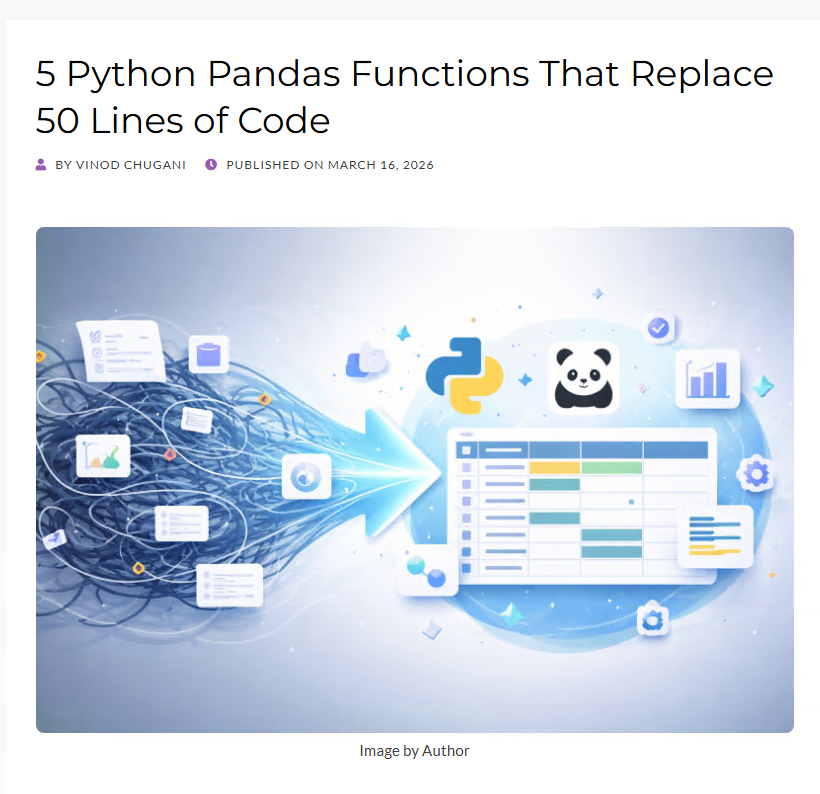






In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

data = {
    'date': pd.date_range('2024-01-01', periods=100, freq='D'),
    'product': np.random.choice(['A', 'B', 'C'], 100),
    'region': np.random.choice(['North', 'South', 'East', 'West'], 100),
    'sales': np.random.randint(100, 1000, 100),
    'costs': np.random.randint(50, 500, 100)
}
df = pd.DataFrame(data)
df

,date,product,region,sales,costs
0,2024-01-01,C,East,705,243
1,2024-01-02,C,West,655,361
2,2024-01-03,C,East,113,64
3,2024-01-04,B,West,516,128
4,2024-01-05,C,West,133,138
...,...,...,...,...,...
95,2024-04-05,B,South,479,284
96,2024-04-06,C,South,247,147
97,2024-04-07,B,South,535,330
98,2024-04-08,C,South,474,53


In [5]:
summary = df.groupby(['product', 'region']).agg({
    'sales': ['sum', 'mean', 'count'],
    'costs': ['sum', 'mean'],
    'date': ['min', 'max']
})
print(summary.head())

               sales                   costs                   date           
                 sum        mean count   sum        mean        min        max
product region                                                                
A       East    3929  491.125000     8  2410  301.250000 2024-01-18 2024-04-01
        North   2410  602.500000     4  1609  402.250000 2024-01-12 2024-03-21
        South   4324  480.444444     9  2199  244.333333 2024-01-08 2024-03-22
        West    5564  556.400000    10  1915  191.500000 2024-01-15 2024-03-24
B       East    3431  490.142857     7  1798  256.857143 2024-01-16 2024-03-26


In [6]:
products = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'category': ['Electronics', 'Furniture', 'Clothing'],
    'margin': [0.3, 0.25, 0.4]
})
enriched = df.merge(products, on='product', how='left')
print(enriched[['product', 'sales', 'category', 'margin']].head())

  product  sales   category  margin
0       C    705   Clothing    0.40
1       C    655   Clothing    0.40
2       C    113   Clothing    0.40
3       B    516  Furniture    0.25
4       C    133   Clothing    0.40


In [7]:
pivot = df.pivot_table(
    values='sales',
    index='product',
    columns='region',
    aggfunc='sum',
    fill_value=0
)
print(pivot)

region   East  North  South  West
product                          
A        3929   2410   4324  5564
B        3431   3946   2549  5230
C        8254   4711   4810  6123


In [8]:
df['profit'] = df['sales'] - df['costs']
df['margin_pct'] = df.apply(
    lambda row: (row['profit'] / row['sales'] * 100) if row['sales'] > 0 else 0,
    axis=1
)
print(df[['sales', 'costs', 'profit', 'margin_pct']].head())

   sales  costs  profit  margin_pct
0    705    243     462   65.531915
1    655    361     294   44.885496
2    113     64      49   43.362832
3    516    128     388   75.193798
4    133    138      -5   -3.759398


In [9]:
filtered = df.query('sales > 500 and region in ["North", "East"]')
print(f"Found {len(filtered)} matching records")
print(filtered[['date', 'product', 'region', 'sales']].head())


Found 26 matching records
         date product region  sales
0  2024-01-01       C   East    705
6  2024-01-07       C  North    866
9  2024-01-10       B  North    547
11 2024-01-12       A  North    736
12 2024-01-13       B  North    871
